# Comparacao QKD: E91 vs BB84

Este notebook executa experimentos comparativos entre os protocolos `QKD_E91` e `QKD_BB84` no QuantumNet.

Objetivos:
- Executar repeticoes para os dois protocolos em topologias diferentes.
- Medir taxa de sucesso, tamanho de chave, custo temporal (timeslot) e consumo de recursos.
- Estimar QBER no BB84 e comparar o comportamento com o E91.

In [1]:
import random

import sys
sys.path.append('../')
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from quantumnet.topology import Network
from quantumnet.control.controller import Controller

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.style.use('default')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 180)

In [2]:
def build_network(topology_name, *topology_args):
    """Cria rede, topologia e rotas para um experimento."""
    net = Network()
    net.set_ready_topology(topology_name, *topology_args)
    Controller(net).register_routing_tables()
    return net


def _get_endpoints(net):
    nodes = sorted(net.hosts.keys())
    return nodes[0], nodes[-1]


def run_e91_trial(topology_name, topology_args, key_size):
    net = build_network(topology_name, *topology_args)
    alice_id, bob_id = _get_endpoints(net)

    t0 = time.perf_counter()
    key = net.application_layer.run_app("QKD_E91", alice_id, bob_id, key_size)
    elapsed_s = time.perf_counter() - t0

    metrics = net.get_metrics(output_type="variable")
    success = key is not None and len(key) == key_size

    return {
        "protocol": "E91",
        "topology": f"{topology_name}{topology_args}",
        "success": success,
        "key_size": len(key) if key is not None else 0,
        "avg_qber": np.nan,
        "elapsed_s": elapsed_s,
        "timeslot": metrics["Total Timeslot"],
        "used_qubits": metrics["Used Qubits"],
        "used_eprs": metrics["Used EPRs"],
        "transport_fidelity": metrics["Transport Layer Fidelity"],
        "link_fidelity": metrics["Link Layer Fidelity"],
        "avg_routes": metrics["Average Routes"],
    }


def run_bb84_trial(topology_name, topology_args, key_size):
    net = build_network(topology_name, *topology_args)
    alice_id, bob_id = _get_endpoints(net)

    t0 = time.perf_counter()
    result = net.application_layer.run_app("QKD_BB84", alice_id, bob_id, key_size)
    elapsed_s = time.perf_counter() - t0

    metrics = net.get_metrics(output_type="variable")
    success = result is not None and len(result["key"]) == key_size

    return {
        "protocol": "BB84",
        "topology": f"{topology_name}{topology_args}",
        "success": success,
        "key_size": len(result["key"]) if result is not None else 0,
        "avg_qber": result["avg_qber"] if result is not None else np.nan,
        "elapsed_s": elapsed_s,
        "timeslot": metrics["Total Timeslot"],
        "used_qubits": metrics["Used Qubits"],
        "used_eprs": metrics["Used EPRs"],
        "transport_fidelity": metrics["Transport Layer Fidelity"],
        "link_fidelity": metrics["Link Layer Fidelity"],
        "avg_routes": metrics["Average Routes"],
    }


def run_experiments(topologies, key_size=32, repetitions=5):
    records = []

    for topology_name, topology_args in topologies:
        for _ in range(repetitions):
            records.append(run_e91_trial(topology_name, topology_args, key_size))
            records.append(run_bb84_trial(topology_name, topology_args, key_size))

    return pd.DataFrame(records)

In [3]:
# Topologias para comparar
# Linha(6), Anel(6), Grade(3x3)
topologies = [
    ("Linha", (6,)),
    ("Anel", (6,)),
    ("Grade", (3, 3)),
]

# Ajuste conforme sua necessidade
KEY_SIZE = 32
REPETITIONS = 5

df = run_experiments(topologies=topologies, key_size=KEY_SIZE, repetitions=REPETITIONS)
df.head()

,protocol,topology,success,key_size,avg_qber,elapsed_s,timeslot,used_qubits,used_eprs,transport_fidelity,link_fidelity,avg_routes
0,E91,"Linha(6,)",True,32,NaN,0.005954,92,284,0,0.000182,0,5.0
1,BB84,"Linha(6,)",True,32,0.163265,0.003869,7,196,0,0.480467,0,5.0
2,E91,"Linha(6,)",True,32,NaN,0.006193,78,242,0,0.000223,0,5.0
3,BB84,"Linha(6,)",True,32,0.163265,0.004030,8,204,0,0.433377,0,5.0
4,E91,"Linha(6,)",True,32,NaN,0.005380,80,248,0,0.000231,0,5.0


In [4]:
summary_protocol = (
    df.groupby("protocol")
      .agg(
          success_rate=("success", "mean"),
          mean_key_size=("key_size", "mean"),
          std_key_size=("key_size", "std"),
          mean_timeslot=("timeslot", "mean"),
          mean_used_qubits=("used_qubits", "mean"),
          mean_used_eprs=("used_eprs", "mean"),
          mean_avg_qber=("avg_qber", "mean"),
      )
      .reset_index()
)

summary_topology = (
    df.groupby(["topology", "protocol"])
      .agg(
          success_rate=("success", "mean"),
          mean_timeslot=("timeslot", "mean"),
          mean_avg_qber=("avg_qber", "mean"),
      )
      .reset_index()
)

print("Resumo por protocolo")
display(summary_protocol)
print("\nResumo por topologia e protocolo")
display(summary_topology)

Resumo por protocolo


,protocol,success_rate,mean_key_size,std_key_size,mean_timeslot,mean_used_qubits,mean_used_eprs,mean_avg_qber
0,BB84,1.0,32.0,0.0,7.466667,411.466667,0.0,0.186252
1,E91,1.0,32.0,0.0,77.400000,240.800000,0.0,NaN



Resumo por topologia e protocolo


,topology,protocol,success_rate,mean_timeslot,mean_avg_qber
0,"Anel(6,)",BB84,1.0,8.8,0.192528
1,"Anel(6,)",E91,1.0,76.0,NaN
2,"Grade(3, 3)",BB84,1.0,6.6,0.222222
3,"Grade(3, 3)",E91,1.0,70.2,NaN
4,"Linha(6,)",BB84,1.0,7.0,0.144005
5,"Linha(6,)",E91,1.0,86.0,NaN


In [5]:
print(summary_protocol[['protocol', 'success_rate', 'mean_avg_qber', 'mean_key_size', 'mean_timeslot']].to_string(index=False))

protocol  success_rate  mean_avg_qber  mean_key_size  mean_timeslot
    BB84           1.0       0.186252           32.0       7.466667
     E91           1.0            NaN           32.0      77.400000


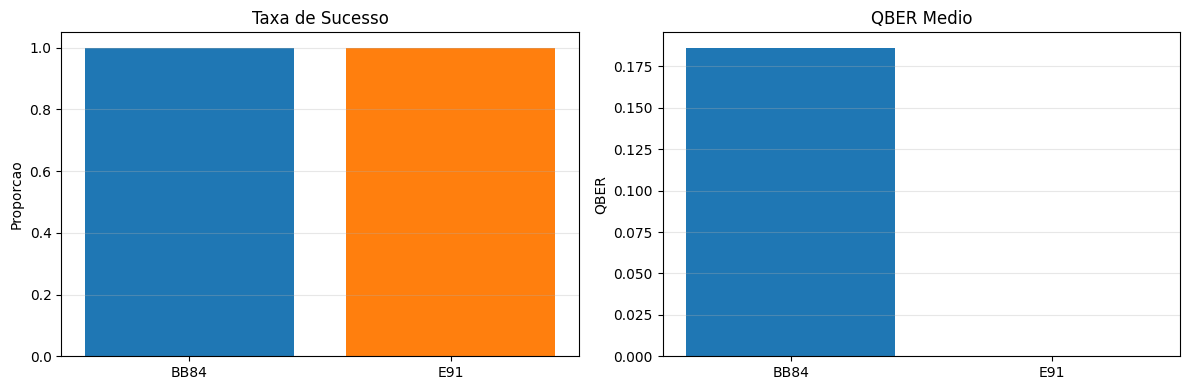

In [6]:
plot_df = summary_protocol.copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(plot_df["protocol"], plot_df["success_rate"], color=["#1f77b4", "#ff7f0e"])
axes[0].set_title("Taxa de Sucesso")
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Proporcao")
axes[0].grid(axis="y", alpha=0.3)

# QBER so existe no BB84; para E91 o valor fica NaN
qber_values = plot_df["mean_avg_qber"].fillna(0.0)
axes[1].bar(plot_df["protocol"], qber_values, color=["#1f77b4", "#ff7f0e"])
axes[1].set_title("QBER Medio")
axes[1].set_ylabel("QBER")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Como interpretar os resultados

- `success_rate`: proporcao de rodadas em que o protocolo entregou a chave alvo.
- `mean_timeslot`: custo temporal medio da simulacao para fechar uma execucao.
- `mean_used_qubits` e `mean_used_eprs`: custo de recursos quanticos.
- `mean_avg_qber`: qualidade do canal no BB84 (quanto menor, melhor).

Sugestoes:
- Aumente `REPETITIONS` para estabilizar estatisticas.
- Teste diferentes tamanhos de topologia e valores de `KEY_SIZE`.
- Ajuste parametros em `quantumnet/default_config.yaml` para estudar sensibilidade a decoerencia e probabilidades.